In [1]:
import numpy as np

In [2]:
data = np.load("opensource_emg_dataset_3_10kh_003.npz")

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(173, 30000, 12)
(173, 30000)
(44, 30000, 12)
(44, 30000)


In [3]:
#pre-activation期予測用ラベル
import numpy as np

def get_onsets(stance):
    d = np.diff(stance)
    return np.where(d == 1)[0] + 1  # stance開始


def make_binary_label(stance, fs=1000, pre_ms=140):

    label = np.zeros_like(stance)

    onsets = get_onsets(stance)
    pre_samples = int(pre_ms * fs / 1000)

    for onset in onsets:

        # 接地100ms前〜接地までを1
        start = max(0, onset - pre_samples)
        label[start:onset + 1] = 1

    return label


#y_train = np.stack([
    #make_binary_label(y) for y in y_train])

#y_val = np.stack([
    #make_binary_label(y) for y in y_val])

In [4]:
#未来接地予測用ラベル
def shift_future_label(
    stance,
    fs=1000,
    future_ms=140
):

    future_samples = int(
        future_ms * fs / 1000
    )

    label = np.zeros_like(
        stance
    )

    label[:-future_samples] = (
        stance[future_samples:]
    )

    return label

y_train = np.stack([
    shift_future_label(y, future_ms=140)
    for y in y_train
])

y_val = np.stack([
    shift_future_label(y, future_ms=140)
    for y in y_val
])

In [5]:
def create_emg_windows(
    X,
    Y,
    window_size=150,
    overlap_samples=130
):
    """
    EMG時系列をwindow化する関数

    Parameters
    ----------
    X : ndarray
        shape = (trial, time, channel)

    Y : ndarray
        shape = (trial, time)

    window_size : int
        窓サイズ

    overlap_samples : int
        オーバーラップするサンプル数

    Returns
    -------
    X_new : ndarray
        shape = (N, window_size, channel)

    Y_new : ndarray
        shape = (N, window_size, 1)
    """

    step = window_size - overlap_samples

    if step <= 0:
        raise ValueError(
            "overlap_samples must be smaller than window_size"
        )

    X_list = []
    Y_list = []

    num_trials = X.shape[0]

    for trial in range(num_trials):

        emg = X[trial]
        label = Y[trial]

        for t in range(window_size, len(emg), step):

            # 入力
            x_window = emg[
                t-window_size:t
            ]

            # 出力
            y_window = label[
                t-window_size:t
            ]

            X_list.append(x_window)
            Y_list.append(y_window)

    X_new = np.array(X_list)
    Y_new = np.array(Y_list)

    # (N, window) → (N, window, 1)
    Y_new = Y_new[..., np.newaxis]

    return X_new, Y_new


In [6]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def create_dataloader(
    X,
    Y,
    batch_size=32,
    shuffle=True
):
    """
    DataLoader作成

    Parameters
    ----------
    X : ndarray
        shape = (N, window, channel)

    Y : ndarray
        shape = (N, window, 1)

    batch_size : int

    shuffle : bool

    Returns
    -------
    loader : DataLoader
    """

    # numpy → torch
    X_tensor = torch.tensor(X, dtype=torch.float32)

    Y_tensor = torch.tensor(Y, dtype=torch.float32)

    # Dataset
    dataset = TensorDataset(X_tensor, Y_tensor)

    # DataLoader
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=True
    )

    return loader

In [7]:
#変数定義
window_size=150
overlap_samples=130
batch_size=32

"""
データの整理
"""
X_train, y_train = create_emg_windows(X_train, y_train, window_size=window_size, overlap_samples=overlap_samples)
X_val, y_val = create_emg_windows(X_val, y_val, window_size=window_size, overlap_samples=overlap_samples)

"""
テンソル化
"""
train_loader = create_dataloader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader = create_dataloader(X_val, y_val, batch_size=batch_size, shuffle=True)

In [8]:
#シード値の固定
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 再現性優先設定（少し遅くなる）
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [9]:
from attention_model import CNN_LSTM_Attention
#from SEBlock_2 import CNN_GRU_Attention
from SEBlock_3_BN import CNN_GRU_Attention

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_GRU_Attention(
    in_channels=12,
    conv_channels_1=16,
    conv_channels_2=32,
    conv_channels_3=64,
    gru_hidden_size=64,
    fc_hidden_size=32,
    dropout_cnn1=0.13000844385332877,
    dropout_cnn2=0.2450249542948521,
    dropout_cnn3=.333294632167325,
    dropout_gru=0.2917753403062322,
    dropout_fc=0.32014556438414565,
    gn_groups_1=4,
    gn_groups_2=8,
    gn_groups_3=8
).to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.00005720423130188003,
    weight_decay=2.118919239321194e-06,
    
)

In [10]:
num_epochs = 50

train_loss_lis = []
val_loss_lis = []

best_val_loss = float('inf')
patience = 10
counter = 0

for epoch in range(num_epochs):
    # ===== train =====
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device, dtype=torch.float32)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    train_loss_lis.append(epoch_train_loss)

    # ===== validation =====
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device, dtype=torch.float32)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            epoch_val_loss += loss.item()

    epoch_val_loss /= len(val_loader)
    val_loss_lis.append(epoch_val_loss)

    print(f"[{epoch+1:03d}/{num_epochs}] Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

    # ===== best model 保存 + early stopping =====
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0

        # ベストモデル保存
        torch.save(model.state_dict(), "best_model_attention6.pth")
        print("Best model saved")

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

# numpy化
train_loss_lis = np.array(train_loss_lis)
val_loss_lis   = np.array(val_loss_lis)

[001/50] Train: 0.4368 | Val: 0.2395
Best model saved
[002/50] Train: 0.2002 | Val: 0.1836
Best model saved
[003/50] Train: 0.1679 | Val: 0.1720
Best model saved
[004/50] Train: 0.1559 | Val: 0.1573
Best model saved
[005/50] Train: 0.1485 | Val: 0.1531
Best model saved
[006/50] Train: 0.1432 | Val: 0.1434
Best model saved
[007/50] Train: 0.1398 | Val: 0.1360
Best model saved
[008/50] Train: 0.1367 | Val: 0.1374
[009/50] Train: 0.1344 | Val: 0.1402
[010/50] Train: 0.1324 | Val: 0.1471
[011/50] Train: 0.1305 | Val: 0.1322
Best model saved
[012/50] Train: 0.1293 | Val: 0.1298
Best model saved
[013/50] Train: 0.1281 | Val: 0.1256
Best model saved
[014/50] Train: 0.1268 | Val: 0.1304
[015/50] Train: 0.1260 | Val: 0.1236
Best model saved
[016/50] Train: 0.1250 | Val: 0.1280
[017/50] Train: 0.1239 | Val: 0.1239
[018/50] Train: 0.1232 | Val: 0.1294
[019/50] Train: 0.1220 | Val: 0.1242
[020/50] Train: 0.1216 | Val: 0.1237
[021/50] Train: 0.1211 | Val: 0.1208
Best model saved
[022/50] Train: 0.1

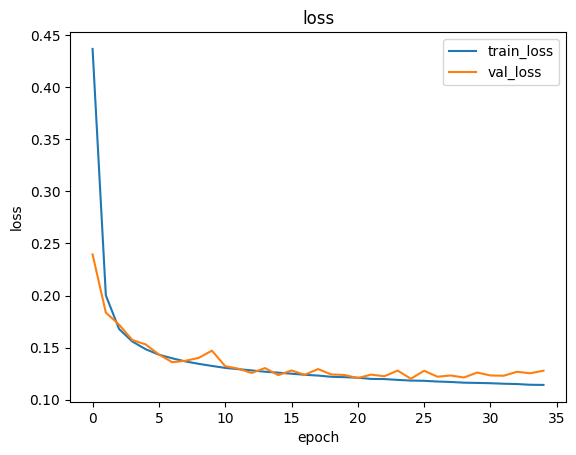

In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np

plt.plot(train_loss_lis,label='train_loss')
plt.plot(val_loss_lis,label='val_loss')
plt.title('loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

In [12]:
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================
# 評価関数
# =========================================
def evaluate_gait_prediction(
    y_true,
    y_prob,
    threshold=0.5,
    fs=1000
):

    y_true = np.squeeze(y_true)
    y_prob = np.squeeze(y_prob)

    # flatten
    y_true_flat = y_true.reshape(-1)
    y_prob_flat = y_prob.reshape(-1)

    # binary化
    y_pred_flat = (y_prob_flat > threshold).astype(int)

    # =============================
    # 分類評価
    # =============================
    accuracy = accuracy_score(
        y_true_flat,
        y_pred_flat
    )

    precision = precision_score(
        y_true_flat,
        y_pred_flat,
        zero_division=0
    )

    recall = recall_score(
        y_true_flat,
        y_pred_flat,
        zero_division=0
    )

    f1 = f1_score(
        y_true_flat,
        y_pred_flat,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true_flat,
        y_prob_flat
    )

    # =============================
    # 接地タイミング誤差
    # =============================
    true_edges = np.where(
        np.diff(y_true_flat.astype(int)) == 1
    )[0]

    pred_edges = np.where(
        np.diff(y_pred_flat.astype(int)) == 1
    )[0]

    timing_errors = []

    for t in true_edges:

        if len(pred_edges) == 0:
            continue

        nearest = pred_edges[
            np.argmin(np.abs(pred_edges - t))
        ]

        error_ms = (
            (nearest - t) / fs
        ) * 1000

        timing_errors.append(error_ms)

    if len(timing_errors) > 0:
        timing_mae = np.mean(
            np.abs(timing_errors)
        )
    else:
        timing_mae = np.nan

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": auc,
        "Timing MAE (ms)": timing_mae
    }

    return metrics


# =========================================
# 推論 + 評価
# =========================================
def run_evaluation(
    model,
    loader,
    device,
    threshold=0.5,
    fs=1000
):

    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            # -----------------
            # モデル出力
            # -----------------
            pred = model(x)

            # sigmoid
            prob = torch.sigmoid(pred)

            # 最終時刻だけ使う場合
            current = prob[:, -1]

            # numpy
            current = current.cpu().numpy()
            y = y[:, -1].cpu().numpy()

            all_probs.append(current)
            all_labels.append(y)

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)

    metrics = evaluate_gait_prediction(
        y_true=y_true,
        y_prob=y_prob,
        threshold=threshold,
        fs=fs
    )

    return metrics

In [15]:
# =========================================
# 予測評価実行コード
# =========================================

import numpy as np
import torch

# -----------------------------
# モデルをeval
# -----------------------------
model.eval()

all_probs = []
all_labels = []

# -----------------------------
# 推論
# -----------------------------
with torch.no_grad():

    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 出力
        logits = model(X_batch)

        # sigmoid
        probs = torch.sigmoid(logits)

        # CPUへ
        probs = probs.cpu().numpy()
        labels = y_batch.cpu().numpy()

        all_probs.append(probs)
        all_labels.append(labels)

# -----------------------------
# numpy結合
# -----------------------------
y_prob = np.concatenate(all_probs, axis=0)
y_true = np.concatenate(all_labels, axis=0)

print(y_prob.shape)
print(y_true.shape)

# =========================================
# 評価
# =========================================

metrics = evaluate_gait_prediction(
    y_true=y_true,
    y_prob=y_prob,
    threshold=0.5,
    fs=1000
)

# =========================================
# 表示
# =========================================

for k, v in metrics.items():

    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

(65664, 150, 1)
(65664, 150, 1)
Accuracy: 0.9504
Precision: 0.9351
Recall: 0.9322
F1-score: 0.9337
ROC-AUC: 0.9907
Timing MAE (ms): 19.6311


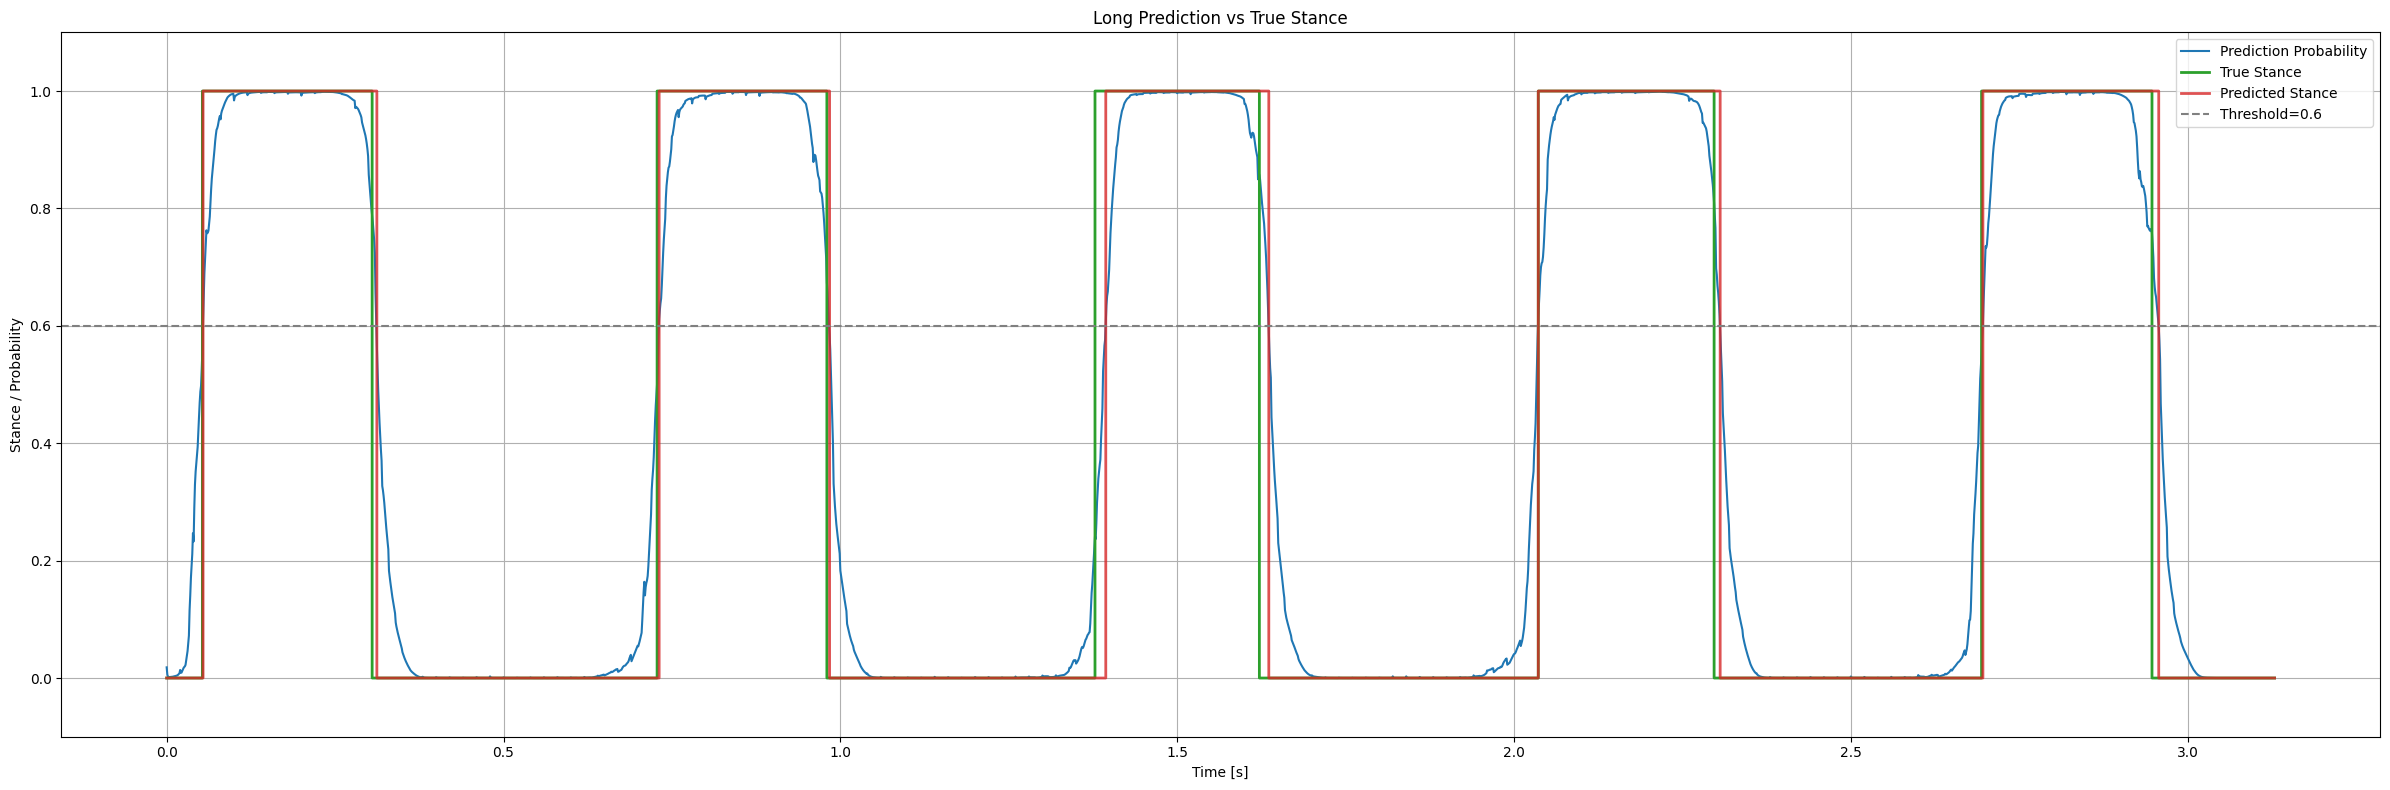

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset


def predict_window_probabilities(model, X_windows, batch_size=64, device="cuda"):
    model.eval()

    dataset = TensorDataset(torch.tensor(X_windows, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    prob_list = []
    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            logits = model(batch_x)
            prob = torch.sigmoid(logits)
            prob_list.append(prob.cpu().numpy())

    return np.concatenate(prob_list, axis=0)


def reconstruct_long_sequence(prob_windows, y_windows, overlap_samples=130, threshold=0.6):
    prob_windows = np.squeeze(prob_windows)
    y_windows = np.squeeze(y_windows)

    if prob_windows.ndim != 2:
        raise ValueError("prob_windows must have shape (N, window_size)")
    if y_windows.ndim != 2:
        raise ValueError("y_windows must have shape (N, window_size)")

    n_windows, window_size = prob_windows.shape
    stride = window_size - overlap_samples
    total_length = stride * (n_windows - 1) + window_size

    prob_sum = np.zeros(total_length, dtype=np.float32)
    true_sum = np.zeros(total_length, dtype=np.float32)
    count = np.zeros(total_length, dtype=np.float32)

    for i in range(n_windows):
        start = i * stride
        end = start + window_size
        prob_sum[start:end] += prob_windows[i]
        true_sum[start:end] += y_windows[i]
        count[start:end] += 1

    prob_long = prob_sum / count
    true_long = (true_sum / count >= 0.5).astype(int)
    pred_long = (prob_long >= threshold).astype(int)

    return prob_long, true_long, pred_long


def plot_long_stance_prediction(
    time,
    prob_long,
    true_long,
    pred_long,
    threshold=0.6,
    title="Long Prediction vs True Stance"
):
    plt.figure(figsize=(24, 8))
    plt.plot(time, prob_long, label="Prediction Probability", color="tab:blue")
    plt.step(time, true_long, where="post", label="True Stance", linewidth=2, color="tab:green")
    plt.step(time, pred_long, where="post", label="Predicted Stance", linewidth=2, color="tab:red", alpha=0.8)
    plt.axhline(threshold, linestyle="--", color="gray", label=f"Threshold={threshold}")
    plt.ylim(-0.1, 1.1)
    plt.xlabel("Time [s]")
    plt.ylabel("Stance / Probability")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_overlapping_prediction(
    model,
    model_path,
    X_windows,
    y_windows,
    overlap_samples=130,
    threshold=0.6,
    fs=1000,
    start_window=0,
    n_windows=None,
    batch_size=64,
    device="cuda"
):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    if n_windows is None:
        n_windows = len(X_windows) - start_window

    X_subset = X_windows[start_window : start_window + n_windows]
    y_subset = y_windows[start_window : start_window + n_windows]

    probs = predict_window_probabilities(model, X_subset, batch_size=batch_size, device=device)
    prob_long, true_long, pred_long = reconstruct_long_sequence(
        probs,
        y_subset,
        overlap_samples=overlap_samples,
        threshold=threshold,
    )

    time = np.arange(len(prob_long)) / fs
    plot_long_stance_prediction(time, prob_long, true_long, pred_long, threshold=threshold)


# ここから実行
plot_overlapping_prediction(
    model=model,
    model_path='C:/Users/masay/Documents/works/ground_contact_prediction_with_OpenSourseData/Machine_Learning/best_model_attention6.pth',
    X_windows=X_val,
    y_windows=y_val,
    overlap_samples=overlap_samples,
    threshold=0.6,
    fs=1000,
    start_window=22000,
    n_windows=150,
    batch_size=64,
    device=device,
)
